In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charge le jeu de données d'attrition client (customer churn) depuis un fichier CSV
df = pd.read_csv("../data/customer_churn.csv")
# Affiche la forme du DataFrame (nombre de lignes, nombre de colonnes)
print(df.shape)
# Affiche les 5 premières lignes du DataFrame pour un aperçu
df.head()

(10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [ ]:
# Affiche un résumé concis du DataFrame, y compris les types de données et le nombre de valeurs non nulles pour chaque colonne.
# Cela aide à identifier les colonnes avec des valeurs manquantes et les types de données actuels.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [ ]:
# Génère des statistiques descriptives pour les colonnes numériques du DataFrame.
# Inclut le compte, la moyenne, l'écart type, le minimum, le maximum et les quartiles, pour comprendre la distribution des données.
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [ ]:
# Calcule le nombre de valeurs manquantes (NaN) pour chaque colonne du DataFrame.
missing = df.isnull().sum()
# Affiche uniquement les colonnes qui ont des valeurs manquantes et leur compte respectif.
missing[missing > 0]

complaint_type    2045
dtype: int64

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


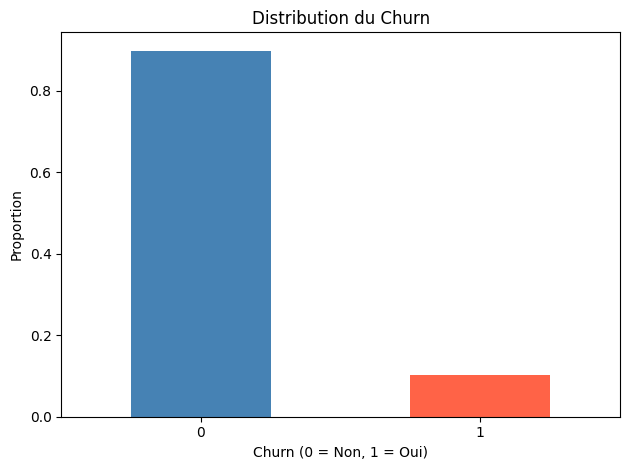

In [ ]:
# Calcule la distribution des valeurs de la colonne 'churn' (0 = pas d'attrition, 1 = attrition).
# `normalize=True` affiche les proportions plutôt que les comptes bruts.
churn_counts = df['churn'].value_counts(normalize=True)
print(churn_counts)

# Trace un diagramme à barres pour visualiser la distribution du churn.
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Distribution du Churn") # Définit le titre du graphique
plt.xlabel("Churn (0 = Non, 1 = Oui)") # Définit l'étiquette de l'axe X
plt.ylabel("Proportion") # Définit l'étiquette de l'axe Y
plt.xticks(rotation=0) # Assure que les étiquettes de l'axe X sont horizontales
plt.tight_layout() # Ajuste la mise en page pour éviter que les étiquettes ne se chevauchent
plt.show() # Affiche le graphique

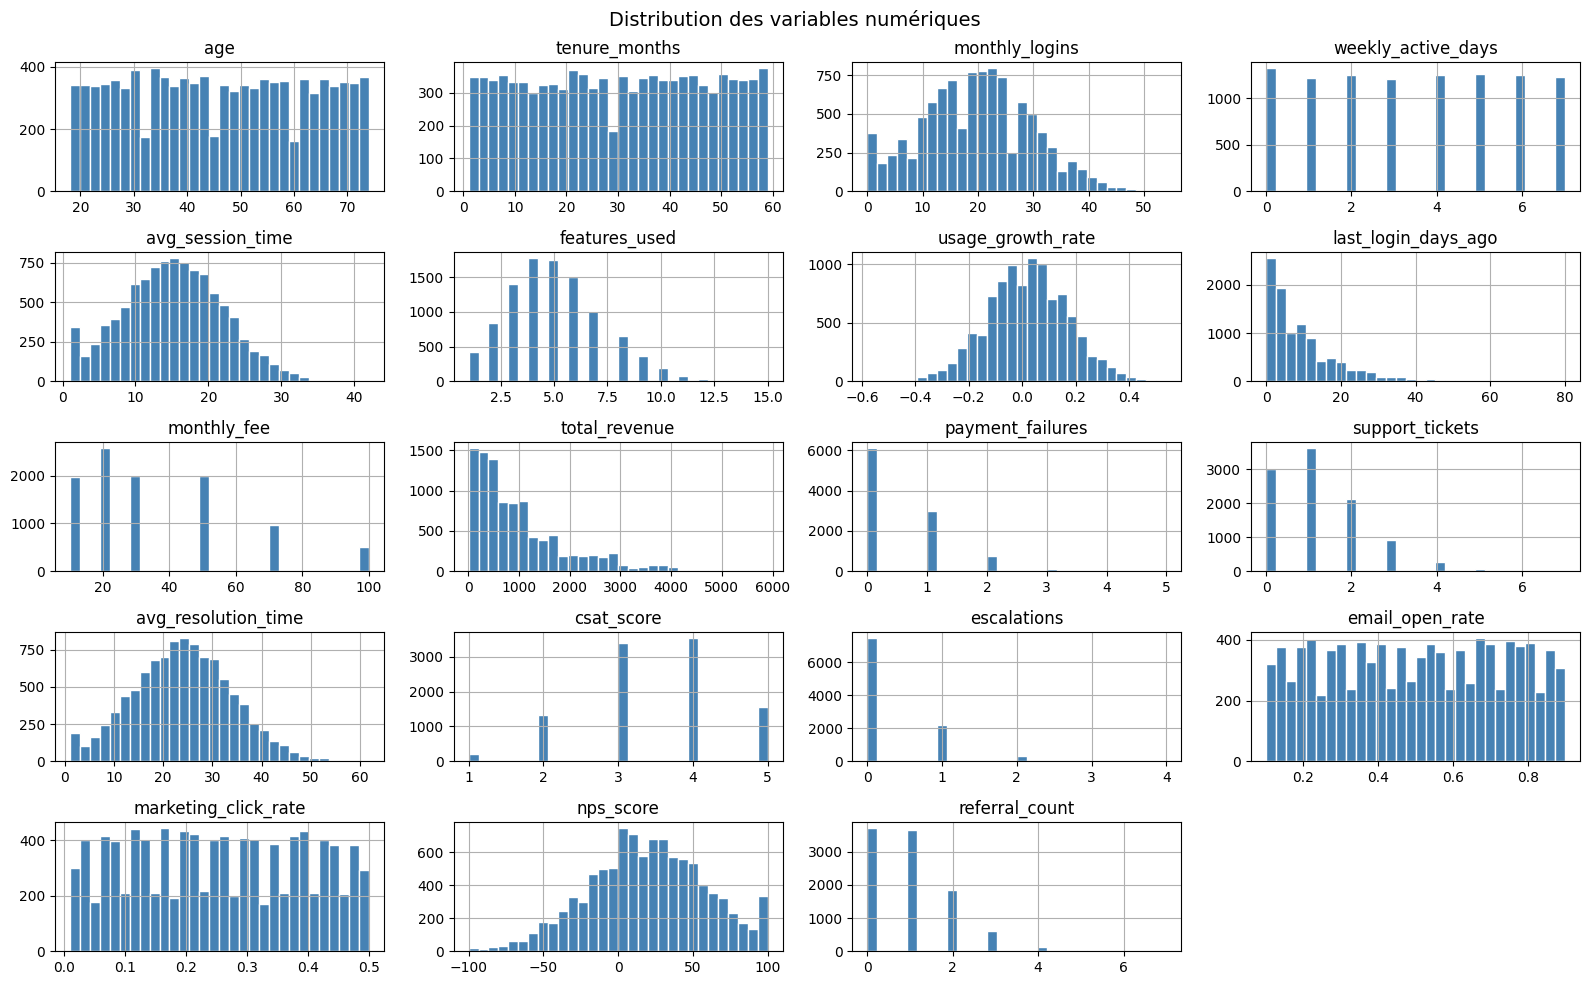

In [ ]:
# Sélectionne toutes les colonnes numériques du DataFrame.
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclut la colonne 'churn' de la liste des colonnes numériques pour l'analyse des distributions des caractéristiques.
num_cols = [col for col in num_cols if col != 'churn']

# Trace des histogrammes pour toutes les colonnes numériques sélectionnées afin de visualiser leurs distributions.
df[num_cols].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle("Distribution des variables numériques", fontsize=14) # Définit le titre général pour tous les sous-graphiques
plt.tight_layout() # Ajuste la mise en page pour éviter le chevauchement des titres/étiquettes
plt.show() # Affiche les graphiques

In [ ]:
# Sélectionne toutes les colonnes de type 'object' (généralement des chaînes de caractères/catégorielles).
# Note: Le 'Pandas4Warning' signale un changement futur dans le comportement de select_dtypes pour les types 'str'.
# Le code actuel sélectionne correctement les colonnes catégorielles de type chaîne.
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Colonnes catégorielles :", cat_cols)

# Itère sur chaque colonne catégorielle et affiche le compte de chaque valeur unique.
# Cela permet de comprendre les catégories présentes et leur fréquence.
for col in cat_cols:
    print(f"\n{col} :")
    print(df[col].value_counts())

Colonnes catégorielles : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

customer_id :
customer_id
CUST_00001    1
CUST_00002    1
CUST_00003    1
CUST_00004    1
CUST_00005    1
             ..
CUST_09996    1
CUST_09997    1
CUST_09998    1
CUST_09999    1
CUST_10000    1
Name: count, Length: 10000, dtype: int64

gender :
gender
Male      5013
Female    4987
Name: count, dtype: int64

country :
country
Bangladesh    1494
Canada        1488
USA           1442
India         1427
Australia     1400
UK            1382
Germany       1367
Name: count, dtype: int64

city :
city
London      1518
Sydney      1471
Dhaka       1459
Delhi       1402
Berlin      1386
New York    1385
Toronto     1379
Name: count, dtype: int64

customer_segment :
customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64



/tmp/ipykernel_96453/3652733030.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


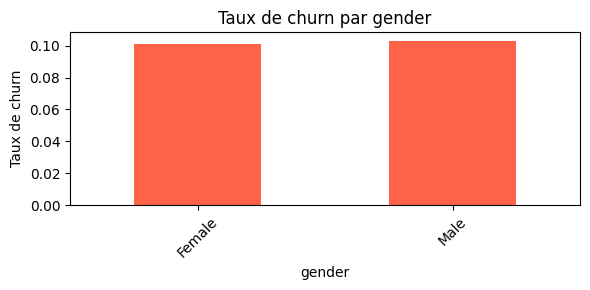

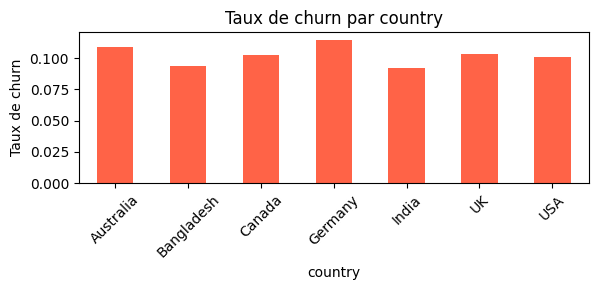

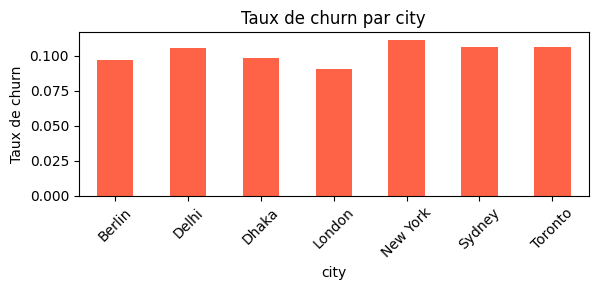

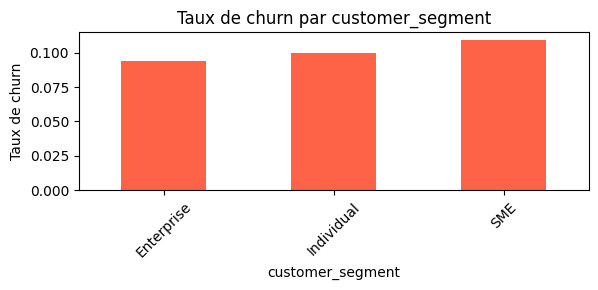

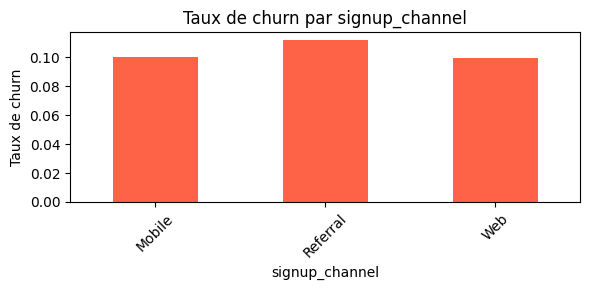

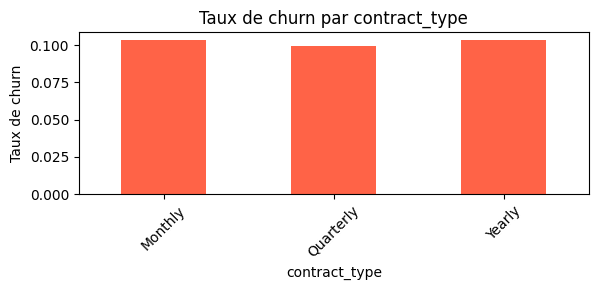

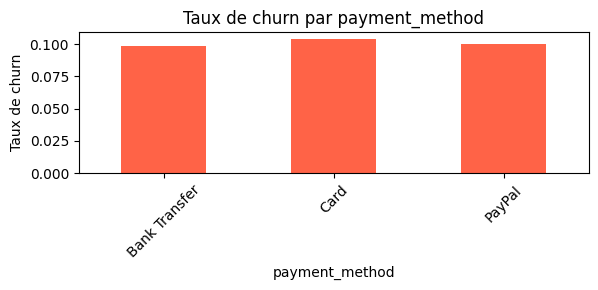

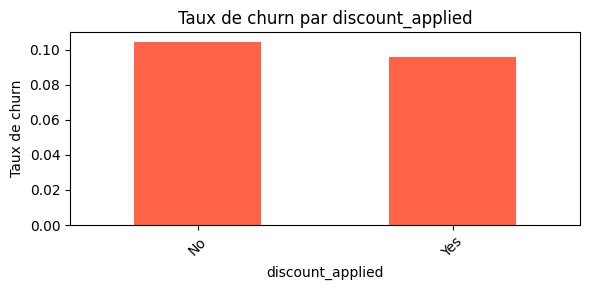

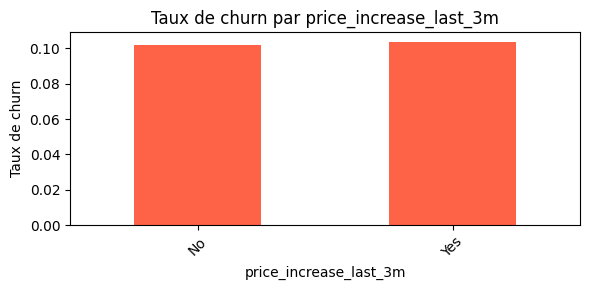

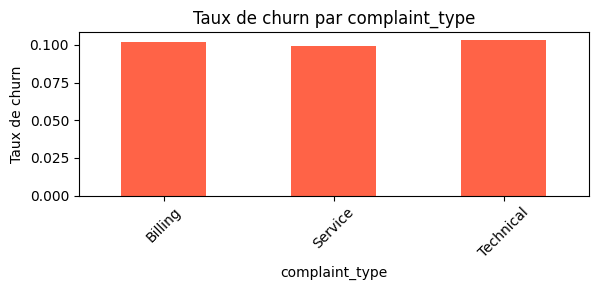

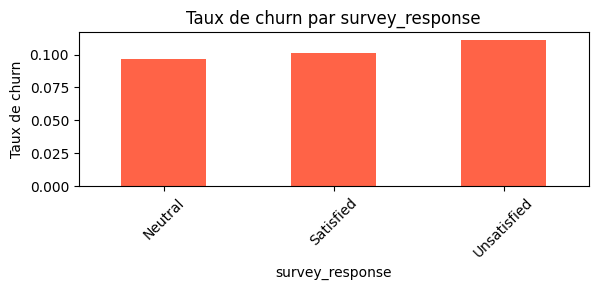

In [ ]:
# Itère sur chaque colonne catégorielle pour analyser le taux d'attrition.
for col in cat_cols:
    # Ignore 'customer_id' car c'est un identifiant unique et n'est pas pertinent pour le regroupement du taux d'attrition.
    if col == 'customer_id':
        continue

    plt.figure(figsize=(6, 3)) # Crée une nouvelle figure pour chaque graphique
    # Regroupe le DataFrame par la colonne catégorielle actuelle et calcule la moyenne du taux d'attrition pour chaque catégorie.
    df.groupby(col)['churn'].mean().plot(kind='bar', color='tomato')
    plt.title(f"Taux de churn par {col}") # Définit le titre du graphique
    plt.ylabel("Taux de churn") # Définit l'étiquette de l'axe Y
    plt.xticks(rotation=45) # Pivote les étiquettes de l'axe X pour une meilleure lisibilité
    plt.tight_layout() # Ajuste la mise en page pour éviter le chevauchement des étiquettes
    plt.show() # Affiche le graphique

<Figure size 600x300 with 0 Axes>

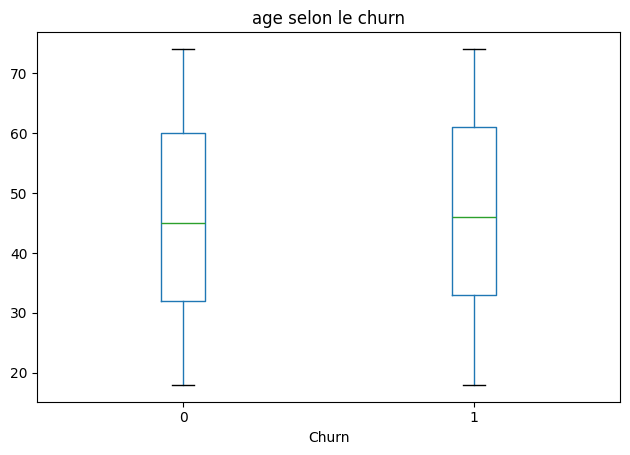

<Figure size 600x300 with 0 Axes>

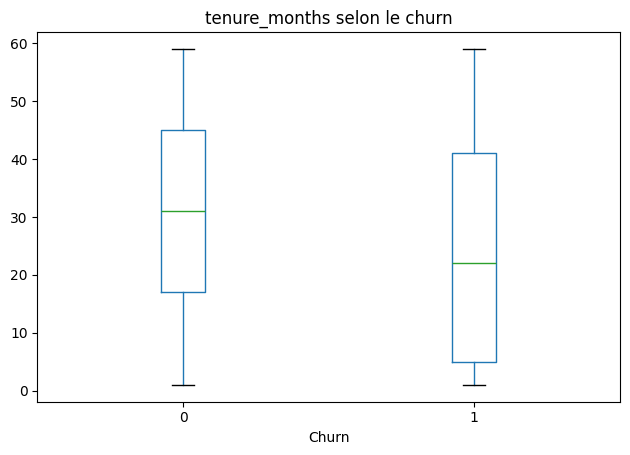

<Figure size 600x300 with 0 Axes>

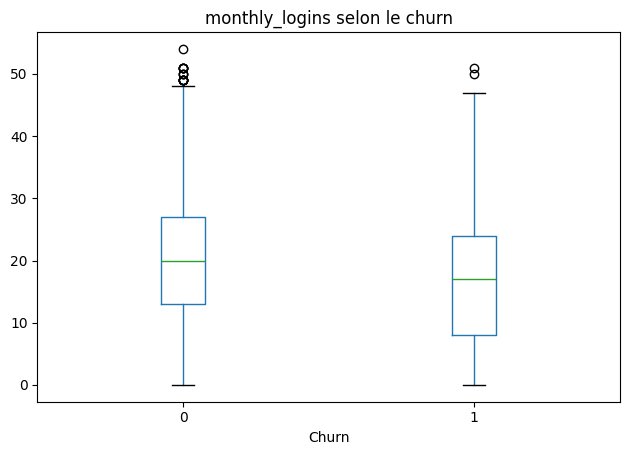

<Figure size 600x300 with 0 Axes>

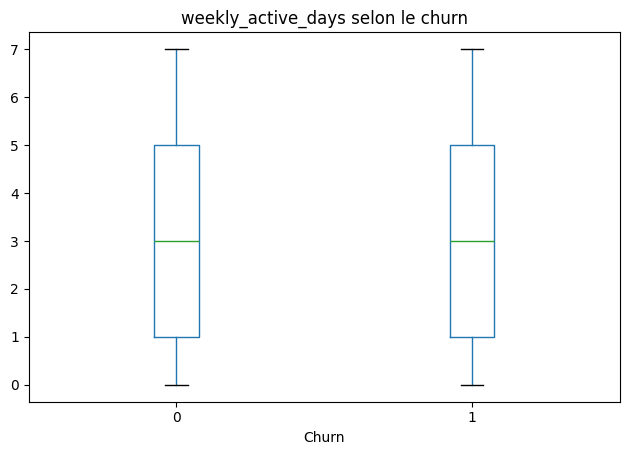

<Figure size 600x300 with 0 Axes>

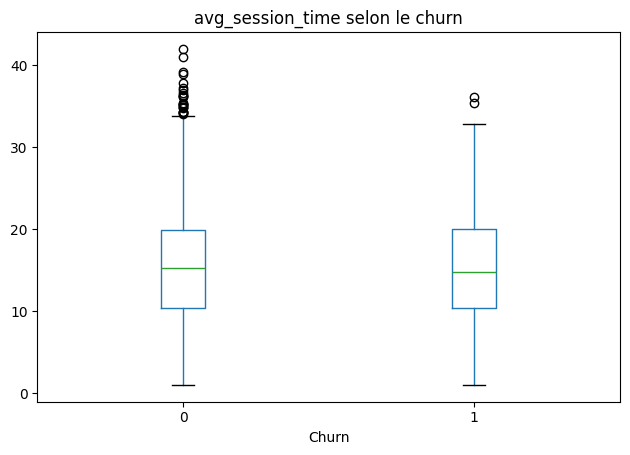

<Figure size 600x300 with 0 Axes>

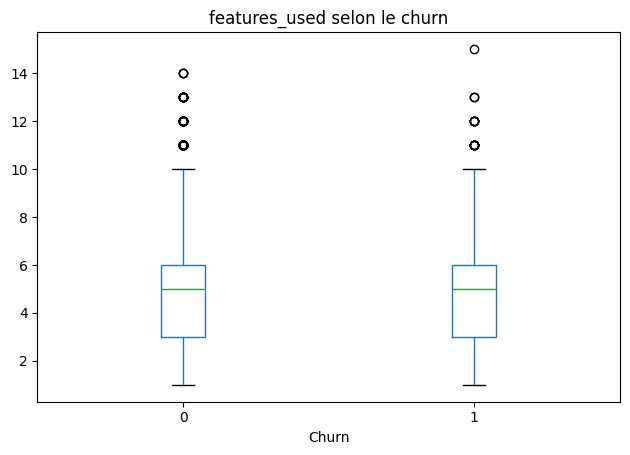

<Figure size 600x300 with 0 Axes>

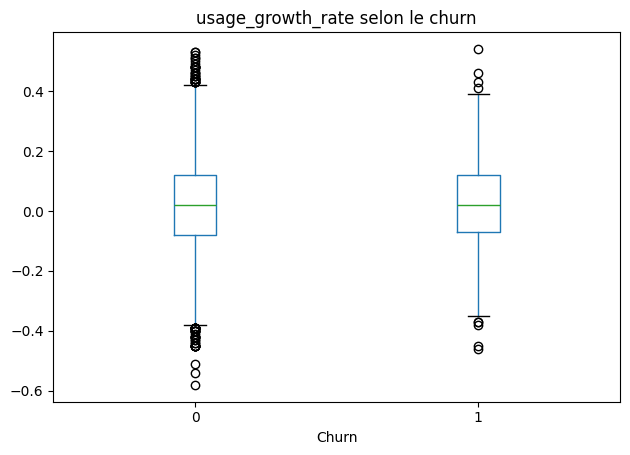

<Figure size 600x300 with 0 Axes>

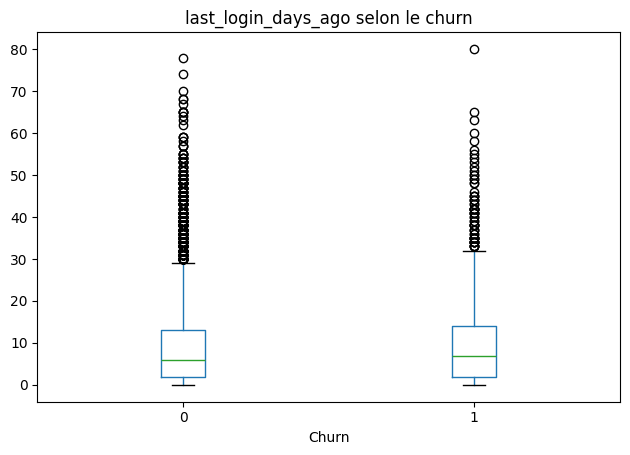

<Figure size 600x300 with 0 Axes>

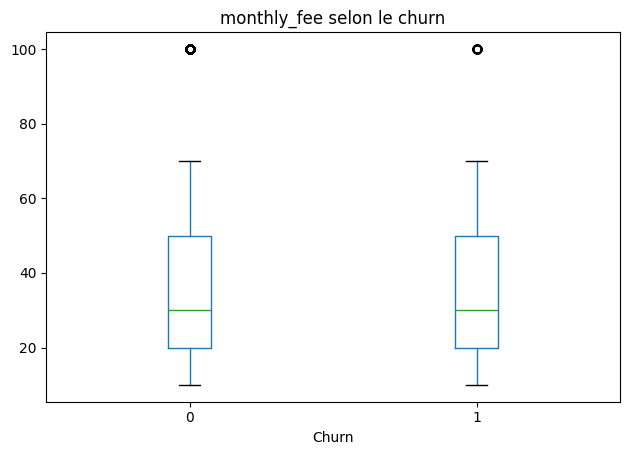

<Figure size 600x300 with 0 Axes>

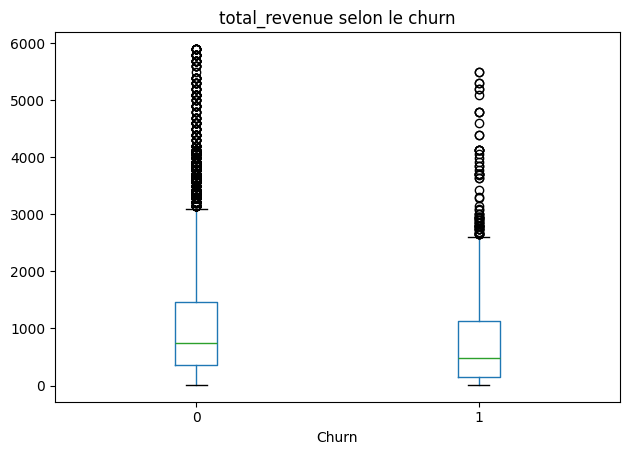

<Figure size 600x300 with 0 Axes>

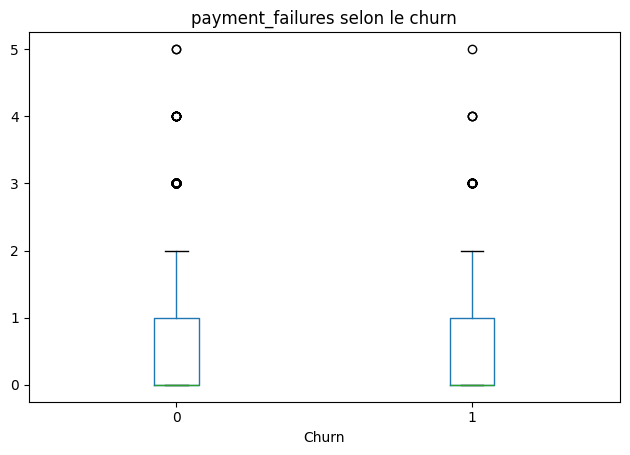

<Figure size 600x300 with 0 Axes>

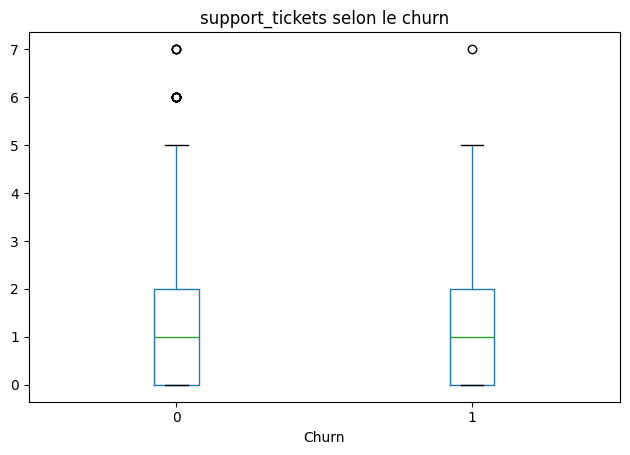

<Figure size 600x300 with 0 Axes>

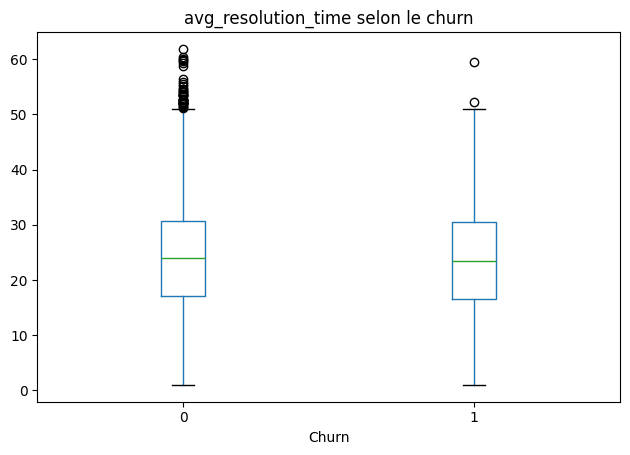

<Figure size 600x300 with 0 Axes>

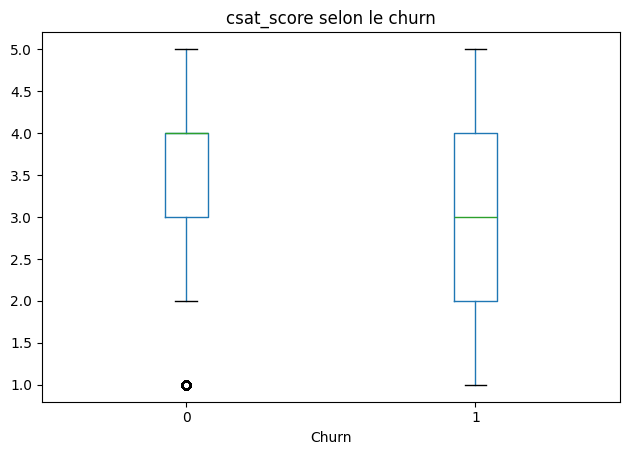

<Figure size 600x300 with 0 Axes>

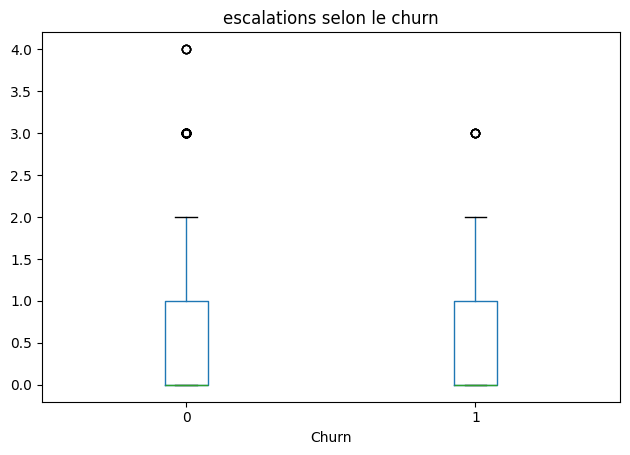

<Figure size 600x300 with 0 Axes>

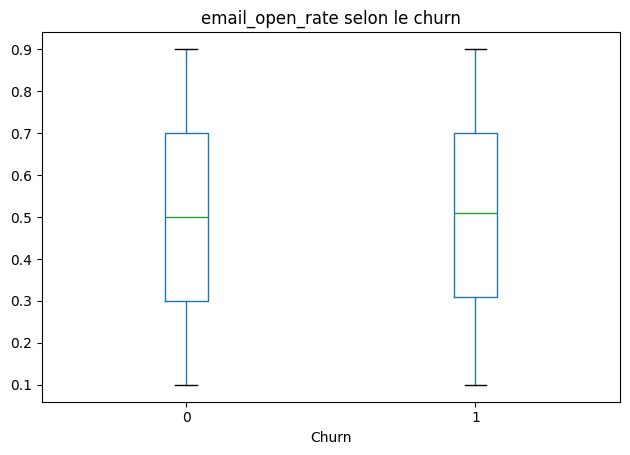

<Figure size 600x300 with 0 Axes>

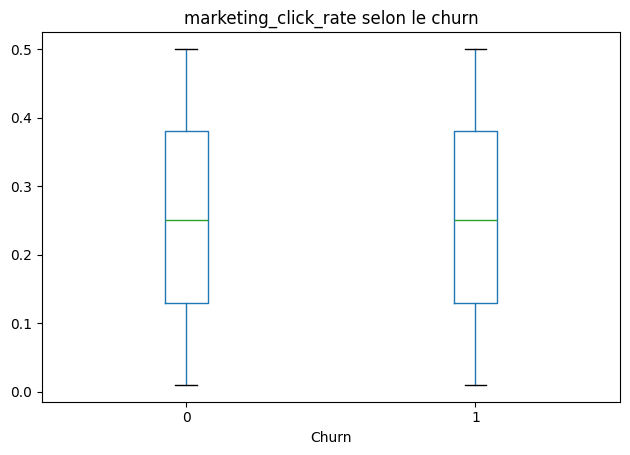

<Figure size 600x300 with 0 Axes>

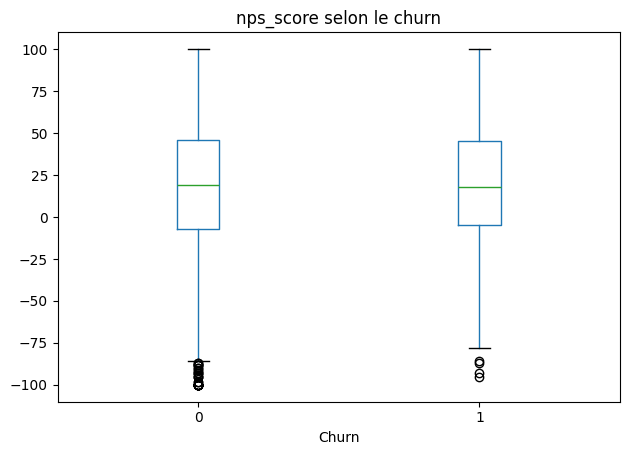

<Figure size 600x300 with 0 Axes>

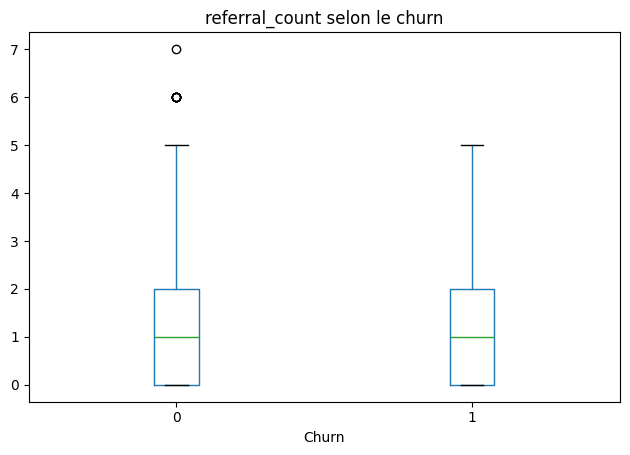

In [ ]:
# Itère sur chaque colonne numérique pour comparer les distributions en fonction du statut d'attrition.
for col in num_cols:
    plt.figure(figsize=(6, 3)) # Crée une nouvelle figure pour chaque graphique
    # Crée un box plot de la colonne numérique, séparé par le statut 'churn'.
    # Cela aide à visualiser si les distributions de caractéristiques numériques diffèrent entre les clients qui partent et ceux qui restent.
    df.boxplot(column=col, by='churn', grid=False)
    plt.title(f"{col} selon le churn") # Définit le titre du graphique
    plt.suptitle("") # Supprime le titre par défaut pour éviter la redondance avec plt.title
    plt.xlabel("Churn") # Définit l'étiquette de l'axe X
    plt.tight_layout() # Ajuste la mise en page pour éviter le chevauchement des étiquettes
    plt.show() # Affiche le graphique

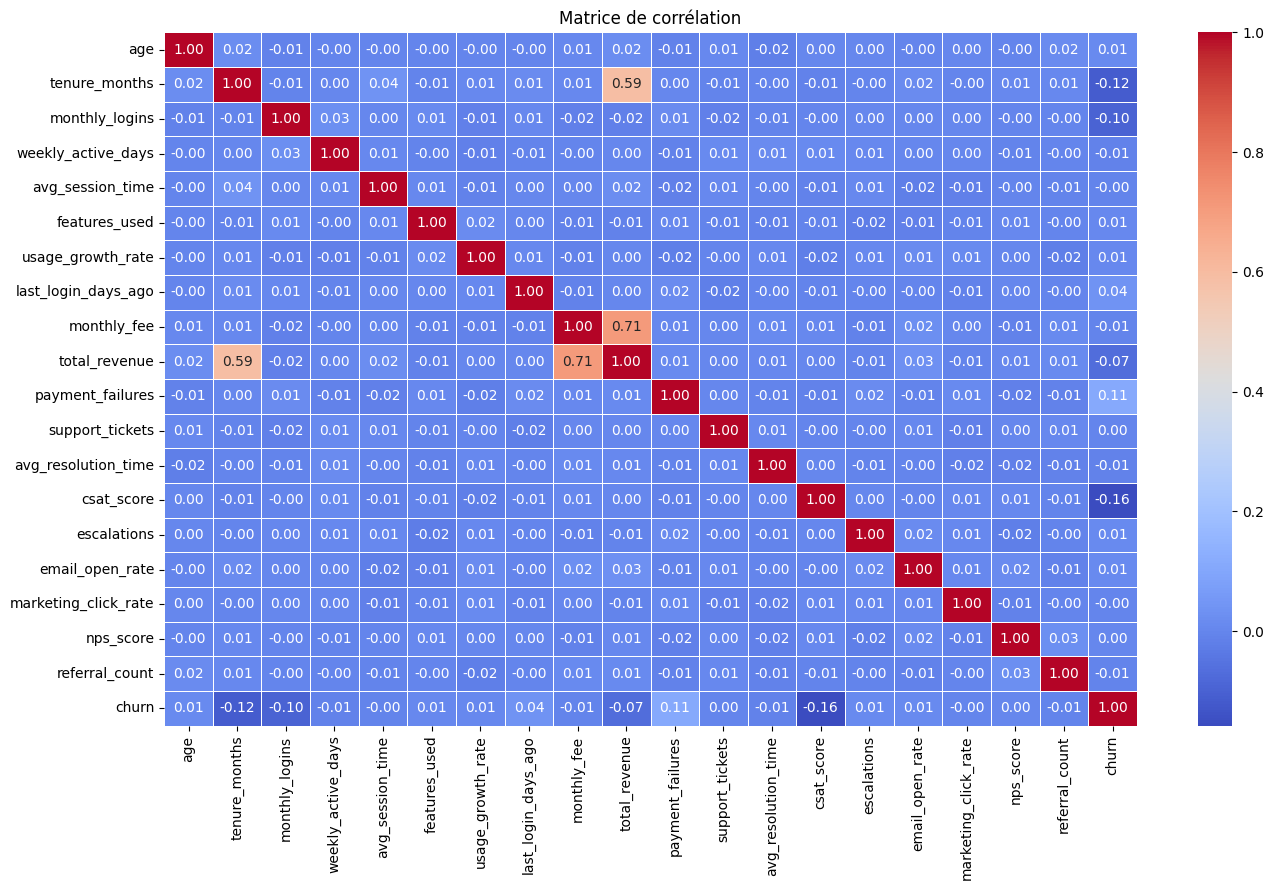

In [ ]:
plt.figure(figsize=(14, 9)) # Définit la taille de la figure pour le graphique
# Crée une carte thermique (heatmap) de la matrice de corrélation pour toutes les colonnes numériques.
sns.heatmap(
    df.select_dtypes(include='number').corr(), # Calcule la matrice de corrélation
    annot=True, # Affiche les valeurs de corrélation sur la carte thermique
    fmt=".2f", # Formate les annotations à deux décimales
    cmap="coolwarm", # Choisit une palette de couleurs pour la carte thermique
    linewidths=0.5 # Ajoute des lignes entre les cellules de la carte thermique
)
plt.title("Matrice de corrélation") # Définit le titre du graphique
plt.tight_layout() # Ajuste la mise en page pour éviter le chevauchement des étiquettes
plt.show() # Affiche le graphique

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Crée une copie du DataFrame et supprime la colonne 'customer_id' car ce n'est pas une caractéristique prédictive.
df_encoded = df.drop(columns=['customer_id'])

# Sélectionne toutes les colonnes de type 'object' (catégorielles) pour l'encodage.
# Note: Le 'Pandas4Warning' signale un changement futur dans le comportement de select_dtypes.
# Le code actuel identifie correctement les colonnes catégorielles de type chaîne pour l'encodage.
cat_cols_to_encode = df_encoded.select_dtypes(include='object').columns
# Applique l'encodage par étiquette (Label Encoding) à chaque colonne catégorielle.
# Cela convertit les valeurs catégorielles en valeurs numériques.
for col in cat_cols_to_encode:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

print(" Encodage terminé") # Message de confirmation de l'encodage
print(f"Shape final : {df_encoded.shape}") # Affiche la forme du DataFrame encodé (nombre de lignes, nombre de colonnes)
df_encoded.head() # Affiche les 5 premières lignes du DataFrame encodé pour vérifier la transformation

 Encodage terminé
Shape final : (10000, 31)


/tmp/ipykernel_96453/1629364510.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_to_encode = df_encoded.select_dtypes(include='object').columns


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,1,68,1,3,2,22,2,0,26,7,...,13.354360,1,4.0,0,0.71,0.40,27,1,1,0
1,0,57,2,5,1,9,0,0,7,5,...,25.140088,0,2.0,0,0.78,0.33,-19,0,2,1
2,1,24,3,4,2,58,2,2,19,5,...,27.572928,1,3.0,0,0.35,0.49,80,0,1,0
3,1,49,0,2,1,19,0,2,34,7,...,26.420822,2,5.0,1,0.83,0.15,100,0,0,0
4,1,65,1,1,1,52,2,0,20,6,...,26.674579,2,4.0,0,0.65,0.44,21,2,1,0


In [ ]:
import sys
# Ajoute le répertoire parent au chemin du système pour permettre l'importation de modules locaux (ex: src).
sys.path.append("..")

from src.train import train_all
# Appelle la fonction `train_all` pour entraîner les modèles.
# Cette fonction gère le prétraitement, le rééquilibrage des classes (SMOTE choisi), et l'entraînement de plusieurs modèles ML.
# Elle retourne les modèles entraînés, les caractéristiques de test (X_test) et les étiquettes de test (y_test).
models, X_test, y_test = train_all()

 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models
Distribution originale — 0: 7183, 1: 817
\ Comparaison des techniques de rééquilibrage (F1) :
  baseline     → F1 moyen : 0.2891 (+/- 0.0108)
  smote        → F1 moyen : 0.7075 (+/- 0.0139)
  oversample   → F1 moyen : 0.6785 (+/- 0.0139)

 Stratégie retenue : SMOTE
Distribution après SMOTE — 0: 7183, 1: 7183

logistic — CV F1: 0.7075 (+/- 0.0139)
 logistic entraîné et sauvegardé

random_forest — CV F1: 0.9547 (+/- 0.0028)
 random_forest entraîné et sauvegardé

xgboost — CV F1: 0.9345 (+/- 0.0040)
 xgboost entraîné et sauvegardé


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i


mlp — CV F1: 0.9335 (+/- 0.0035)
 mlp entraîné et sauvegardé


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models

Modèle : logistic
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      1796
           1       0.18      0.64      0.28       204

    accuracy                           0.67      2000
   macro avg       0.56      0.66      0.54      2000
weighted avg       0.87      0.67      0.74      2000

ROC-AUC : 0.7197
PR-AUC  : 0.2402
Recall  : 0.6373

Modèle : random_forest
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1796
           1       0.30      0.05      0.09       204

    accuracy                           0.89      2000
   macro avg       0.60      0.52      0.52      2000
weighted avg       0.84      0.89      0.85      2000

ROC-AUC : 0.7829
PR-AUC  : 0.2597
Recall  : 0.0539

Modèle : xgboost
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    

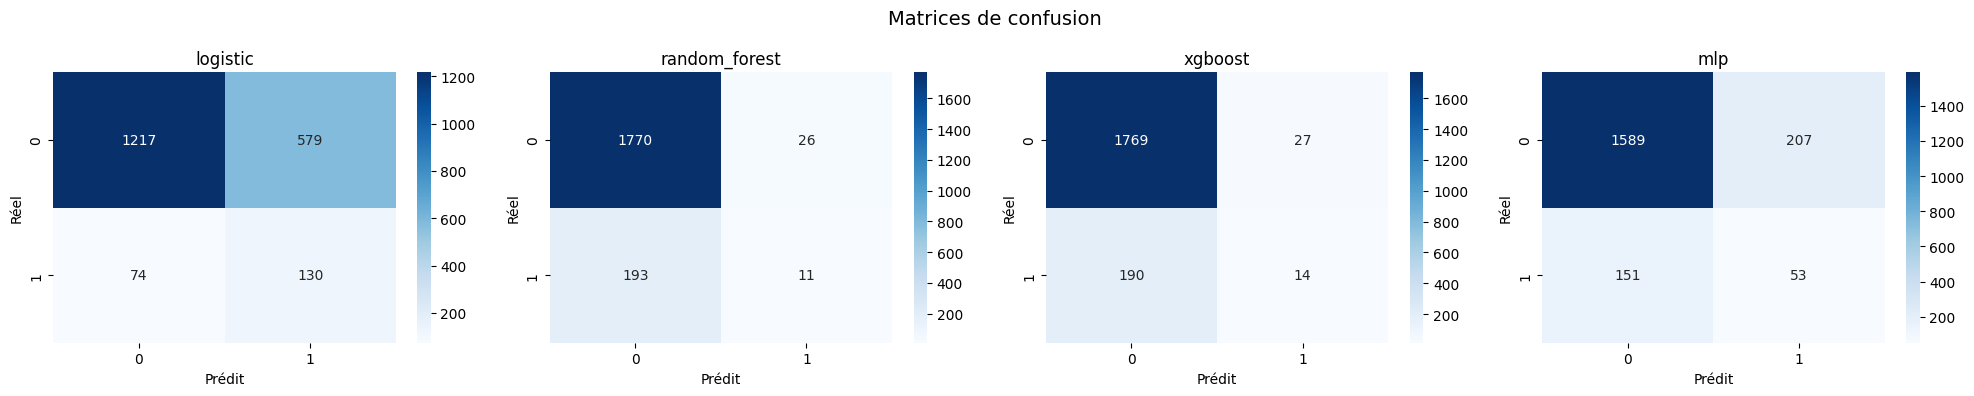

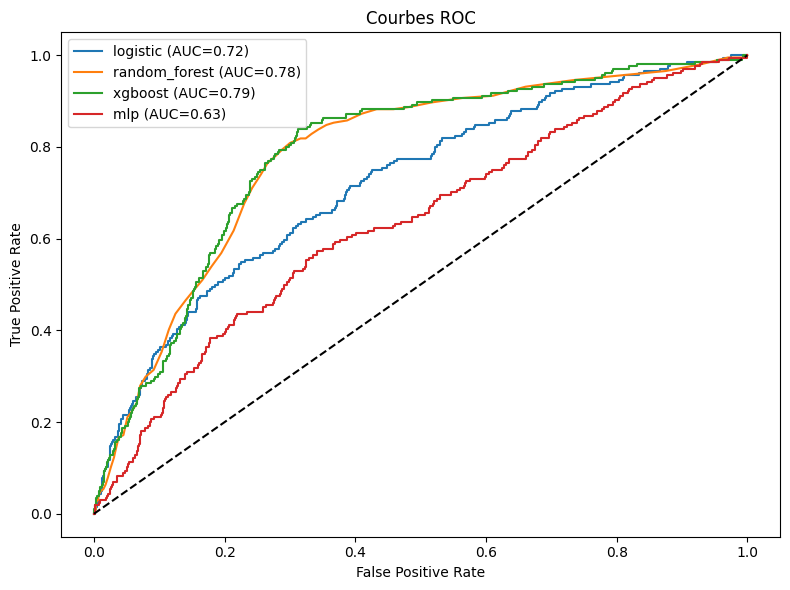

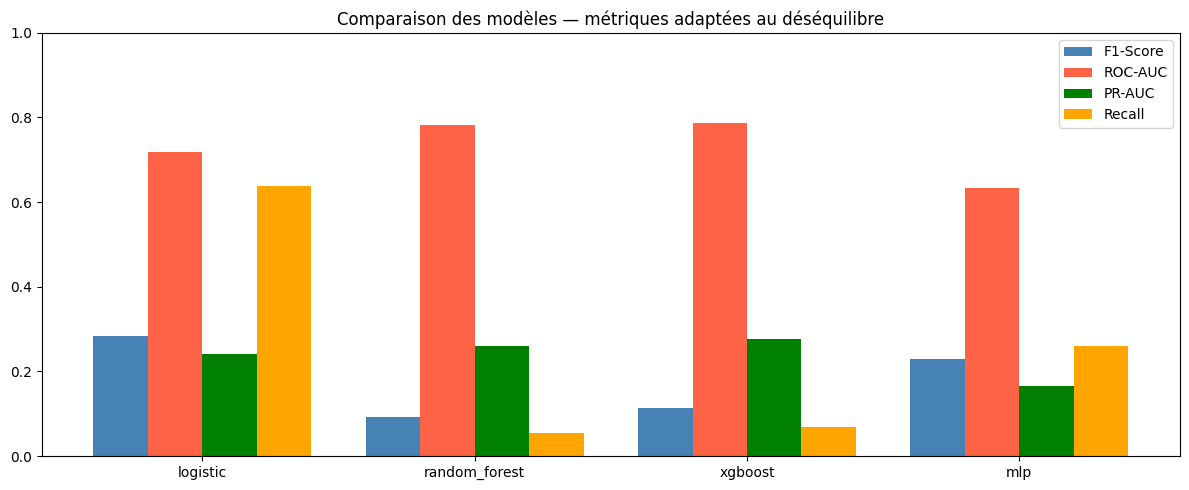

In [ ]:
from src.evaluate import evaluate_all, plot_confusion_matrices, plot_roc_curves, plot_comparison

# Évalue tous les modèles entraînés en utilisant un ensemble de test séparé.
# Retourne les résultats d'évaluation (metrics) et les vraies étiquettes de test.
results, y_test = evaluate_all()
# Trace les matrices de confusion pour chaque modèle afin de visualiser les vrais positifs, faux positifs, etc.
plot_confusion_matrices(results, y_test)
# Trace les courbes ROC (Receiver Operating Characteristic) pour chaque modèle.
# Cela aide à évaluer la capacité du modèle à distinguer les classes.
plot_roc_curves(results, y_test)
# Trace une comparaison des métriques de performance clés pour tous les modèles.
plot_comparison(results)

 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models
Type shap_values : <class 'numpy.ndarray'>
Shape : (200, 30, 2)
 SHAP Summary Plot (global)


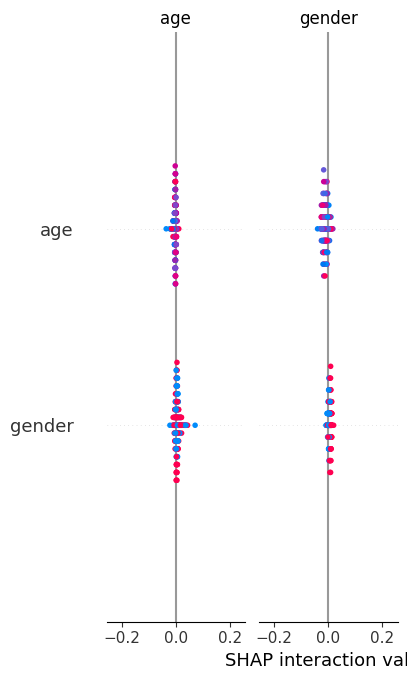

 SHAP Bar Plot


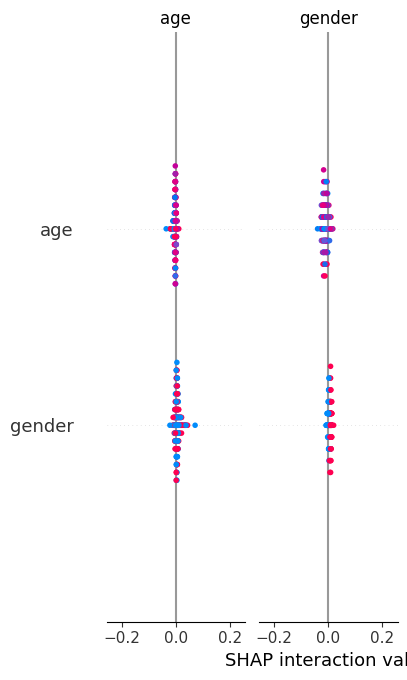

In [ ]:
import importlib
import src.shap_analysis
# Recharge le module `src.shap_analysis` pour s'assurer que les dernières modifications sont prises en compte.
importlib.reload(src.shap_analysis)

from src.shap_analysis import run_shap
# Exécute l'analyse SHAP (SHapley Additive exPlanations) pour interpréter les prédictions des modèles.
# Cela permet de comprendre l'importance des caractéristiques et leur impact sur la prédiction d'attrition.
run_shap()

In [ ]:
import importlib
import src.preprocessing, src.train
# Recharge les modules `src.preprocessing` et `src.train`.
importlib.reload(src.preprocessing)
importlib.reload(src.train)

from src.train import train_all
# Ré-exécute le processus d'entraînement des modèles.
# Ceci est une duplication de la cellule 74a9ac59 et recharge et entraîne les modèles à nouveau.
models, X_test, y_test = train_all()

 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models
Distribution originale — 0: 7183, 1: 817
\ Comparaison des techniques de rééquilibrage (F1) :
  baseline     → F1 moyen : 0.2891 (+/- 0.0108)
  smote        → F1 moyen : 0.7075 (+/- 0.0139)
  oversample   → F1 moyen : 0.6785 (+/- 0.0139)

 Stratégie retenue : SMOTE
Distribution après SMOTE — 0: 7183, 1: 7183

logistic — CV F1: 0.7075 (+/- 0.0139)
 logistic entraîné et sauvegardé

random_forest — CV F1: 0.9547 (+/- 0.0028)
 random_forest entraîné et sauvegardé

xgboost — CV F1: 0.9345 (+/- 0.0040)
 xgboost entraîné et sauvegardé


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i


mlp — CV F1: 0.9335 (+/- 0.0035)
 mlp entraîné et sauvegardé


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
import pandas as pd
import os

# Définit le répertoire de base pour les chemins de fichiers (utile pour la portabilité).
BASE_DIR  = os.path.dirname(os.path.abspath(".."))
# Recharge le jeu de données d'attrition client depuis un fichier CSV (cette étape est redondante si le DF est déjà chargé).
df = pd.read_csv("../data/customer_churn.csv")
# Affiche la liste des noms de colonnes du DataFrame.
print(list(df.columns))
# Affiche la forme (nombre de lignes, nombre de colonnes) du DataFrame.
print(df.shape)

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']
(10000, 32)


In [ ]:
# Affiche les comptes bruts des valeurs de la colonne 'churn'.
print(df['churn'].value_counts())
# Affiche les comptes normalisés (proportions) des valeurs de la colonne 'churn'.
# Cette information est déjà obtenue et visualisée dans la cellule 6c0d6584 (information dupliquée).
print(df['churn'].value_counts(normalize=True))

churn
0    8979
1    1021
Name: count, dtype: int64
churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models
Distribution originale — 0: 7183, 1: 817
\ Comparaison des techniques de rééquilibrage (F1) :
  baseline     → F1 moyen : 0.2891 (+/- 0.0108)
  smote        → F1 moyen : 0.7075 (+/- 0.0139)
  oversample   → F1 moyen : 0.6785 (+/- 0.0139)

 Stratégie retenue : SMOTE
Distribution après SMOTE — 0: 7183, 1: 7183

logistic — CV F1: 0.7075 (+/- 0.0139)
 logistic entraîné et sauvegardé

random_forest — CV F1: 0.9547 (+/- 0.0028)
 random_forest entraîné et sauvegardé

xgboost — CV F1: 0.9345 (+/- 0.0040)
 xgboost entraîné et sauvegardé


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i


mlp — CV F1: 0.9335 (+/- 0.0035)


/home/diomande-brakissa/Documents/churn-project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 mlp entraîné et sauvegardé
 Scaler sauvegardé dans : /home/diomande-brakissa/Documents/churn-project/models

Modèle : logistic
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      1796
           1       0.18      0.64      0.28       204

    accuracy                           0.67      2000
   macro avg       0.56      0.66      0.54      2000
weighted avg       0.87      0.67      0.74      2000

ROC-AUC : 0.7197
PR-AUC  : 0.2402
Recall  : 0.6373

Modèle : random_forest
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1796
           1       0.30      0.05      0.09       204

    accuracy                           0.89      2000
   macro avg       0.60      0.52      0.52      2000
weighted avg       0.84      0.89      0.85      2000

ROC-AUC : 0.7829
PR-AUC  : 0.2597
Recall  : 0.0539

Modèle : xgboost
              precision    recall  f1-score   support

           0       

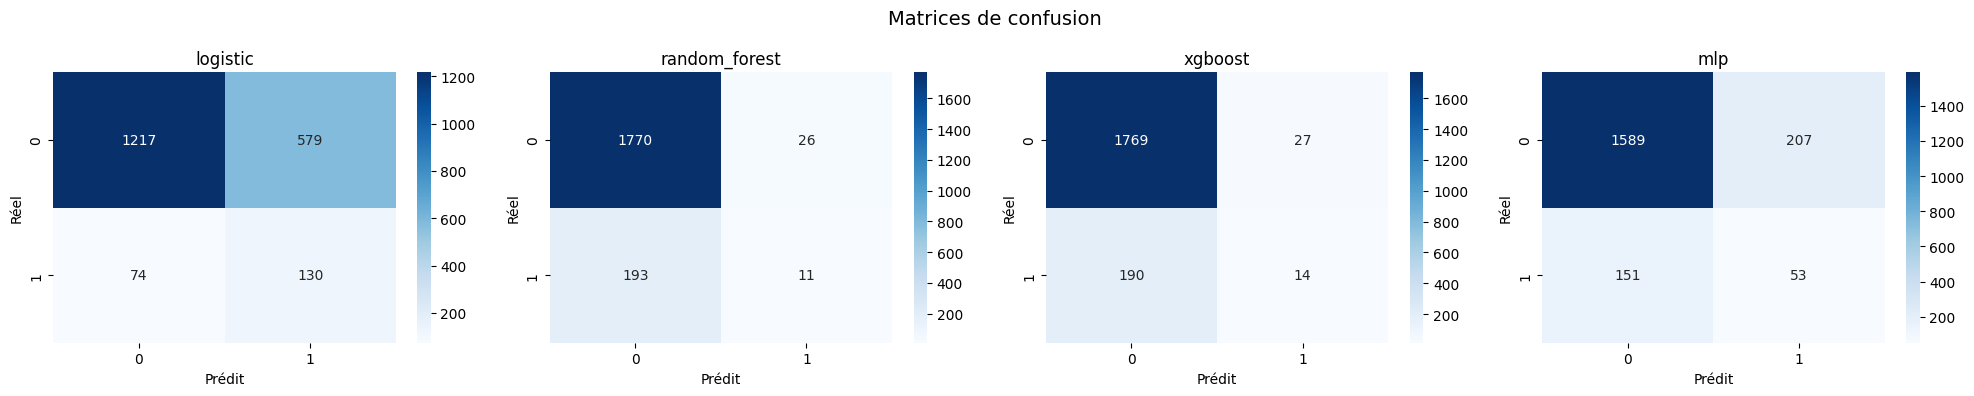

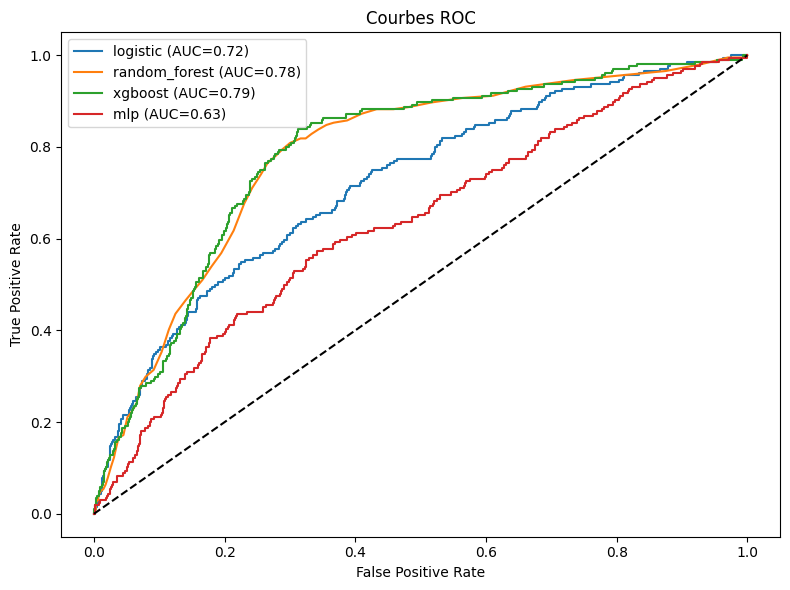

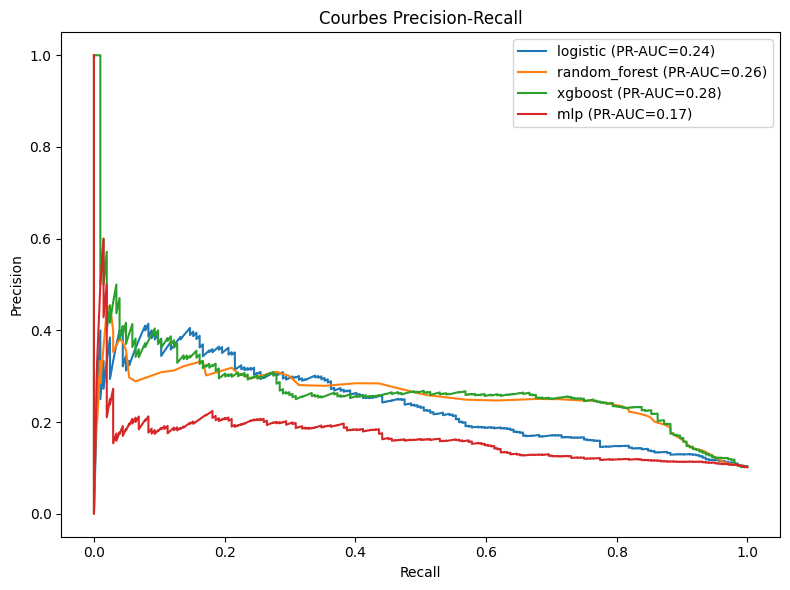

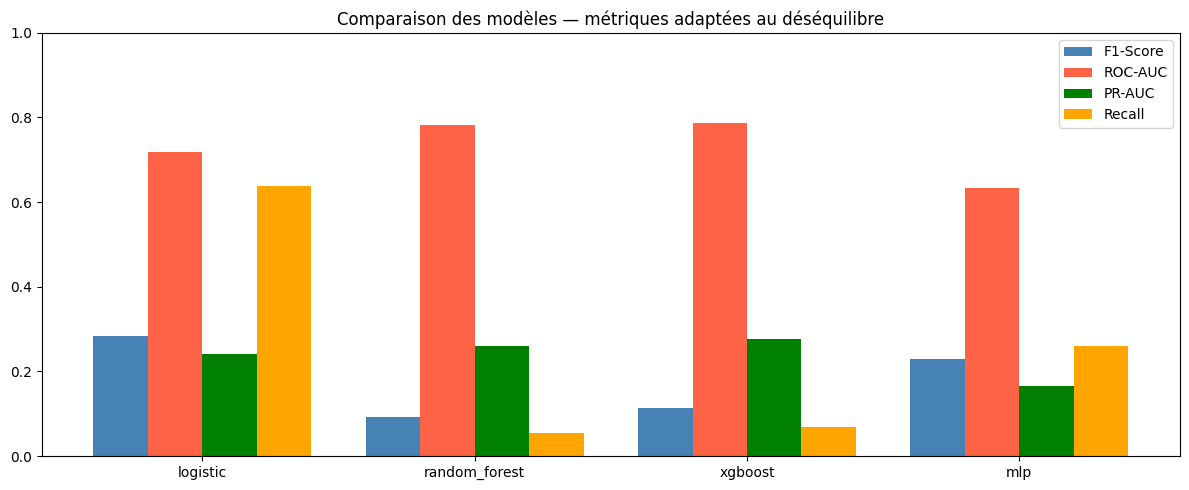

In [ ]:
import importlib
import src.preprocessing, src.train, src.evaluate
# Recharge les modules `src.preprocessing`, `src.train` et `src.evaluate`.
# Cela garantit que les dernières modifications apportées à ces modules sont utilisées.
importlib.reload(src.preprocessing)
importlib.reload(src.train)
importlib.reload(src.evaluate)

from src.train import train_all
from src.evaluate import evaluate_all, plot_confusion_matrices, plot_roc_curves, plot_pr_curves, plot_comparison

# Entraîne les modèles en gérant le déséquilibre des classes (par exemple, en utilisant SMOTE).
# Retourne les modèles entraînés, les caractéristiques de test (X_test) et les étiquettes de test (y_test).
models, X_test, y_test = train_all()

# Effectue une évaluation complète des modèles entraînés.
# Retourne les résultats d'évaluation et les vraies étiquettes de test.
results, y_test = evaluate_all()
# Trace les matrices de confusion pour tous les modèles.
plot_confusion_matrices(results, y_test)
# Trace les courbes ROC pour tous les modèles.
plot_roc_curves(results, y_test)
# Trace les courbes de Précision-Rappel (PR) pour tous les modèles.
plot_pr_curves(results, y_test)
# Trace une comparaison des métriques de performance des modèles.
plot_comparison(results)

## Résumé Global de l'Analyse du churn d'un client

Notre analyse a exploré un ensemble de données en suivant les étapes suivantes :

### 1. Exploration et Nettoyage des Données

*   **Chargement et Aperçu :** Le jeu de données `customer_churn.csv` a été chargé, révélant 10 000 entrées et 32 colonnes. Un aperçu rapide a montré la structure des données.
*   **Informations sur les Données :** L'analyse `df.info()` a confirmé les types de données et a identifié une seule colonne avec des valeurs manquantes : `complaint_type` (2045 valeurs manquantes).
*   **Statistiques Descriptives :** `df.describe()` a fourni des statistiques clés pour les variables numériques, permettant de comprendre leur distribution, leurs valeurs min/max et leurs tendances centrales.
*   **Valeurs Manquantes :** La colonne `complaint_type` a été identifiée comme ayant des valeurs manquantes.

### 2. Analyse Exploratoire des Données (EDA)

*   **Distribution du Churn :** Il a été observé que seulement environ 10,21 % des clients ont churné, indiquant un déséquilibre important des classes.
*   **Distributions Numériques :** Des histogrammes ont été générés pour toutes les variables numériques pour visualiser leurs distributions.
*   **Analyse des Catégories :** Les colonnes catégorielles ont été listées, et la fréquence de chaque catégorie a été affichée, révélant des distributions variées pour des caractéristiques comme le `country`, `city`, `customer_segment`, `signup_channel`, `contract_type`, `payment_method`, `discount_applied`, `price_increase_last_3m`, `complaint_type` et `survey_response` (Cell a5469076).
*   **Taux de Churn par Catégorie :** Des diagrammes à barres ont montré le taux de churn moyen pour chaque catégorie des variables qualitatives.
*   **Box Plots Numériques vs Churn :** Des box plots ont été utilisés pour visualiser les différences de distribution des variables numériques entre les clients qui churnent et ceux qui ne churnent pas, aidant à identifier des caractéristiques potentiellement discriminantes (Cell e9d46a7b).
*   **Matrice de Corrélation :** Une carte thermique a affiché la corrélation entre toutes les variables numériques, mettant en évidence les relations linéaires entre elles.

### 3. Prétraitement des Données

*   **Encodage des Variables Catégorielles :** La colonne `customer_id` a été supprimée, et toutes les colonnes catégorielles restantes ont été encodées numériquement à l'aide de `LabelEncoder` pour les rendre utilisables par les modèles d'apprentissage automatique. Le DataFrame encodé a désormais une forme de (10000, 31).

### 4. Entraînement et Évaluation des Modèles

*   **Pipelines de Modélisation :** Le processus d'entraînement a été géré via des modules `src.train` et `src.evaluate`, incluant le prétraitement (mise à l'échelle), la gestion du déséquilibre des classes (SMOTE s'est avéré la meilleure technique avec un F1 moyen de 0.7075) et l'entraînement de plusieurs modèles (régression logistique, forêt aléatoire, XGBoost, MLP).
*   **Évaluation des Performances :** Les modèles ont été évalués sur un ensemble de test, et des métriques clés comme la précision, le rappel, le score F1 et l'AUC-ROC ont été calculées et visualisées via des matrices de confusion, des courbes ROC et PR, et des graphiques comparatifs.

    *   **Logistic Regression** : A montré un rappel élevé pour la classe 1 (churn) mais une précision très faible, ce qui est typique pour un modèle qui sur-prédit la classe minoritaire pour s'assurer de ne pas la manquer.
    *   **Random Forest** et **XGBoost** : Ont montré de bonnes performances globales (précision élevée pour la classe 0), mais un rappel très faible pour la classe 1, ce qui indique qu'ils ont du mal à identifier les clients qui vont churner.
    *   **MLP** : A eu des performances intermédiaires, avec un rappel légèrement meilleur que les modèles basés sur les arbres pour la classe 1, mais des scores de précision et F1 plus faibles dans l'ensemble.

### 5. Interprétabilité du Modèle

*   **Analyse SHAP :** L'analyse SHAP a été exécutée pour fournir une interprétation de l'importance des caractéristiques et de leur impact sur les prédictions des modèles. Cela a permis de comprendre quelles caractéristiques contribuent le plus à la prédiction des clients qui vont churner.

En résumé, l'analyse a permis d'identifier les caractéristiques importantes et d'entraîner plusieurs modèles prédictifs. Cependant, la détection précise des clients qui churnent reste un défi en raison du fort déséquilibre des classes, comme en témoignent les faibles scores de rappel pour la classe 1 (churn) dans la plupart des modèles, malgré l'utilisation de techniques de rééquilibrage comme SMOTE. Le modèle de régression logistique, bien que moins précis, a montré le meilleur rappel pour la classe de prédiction, ce qui pourrait être un point de départ pour des optimisations futures.